<a href="https://colab.research.google.com/github/Vrinda-2004/Assessmenttest/blob/main/Supervised_learning_case_study_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

In [3]:

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [4]:
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [5]:
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")
sample_submission = pd.read_csv("/content/sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (94, 14)
Test shape: (41, 13)
Sample submission shape: (3, 2)


In [6]:
train.head()


,id,sexo,longitudCraneo,longitudPico,longitudNarina,anchoCraneo,altoPico,anchoPico,tarso,longAlaCerrada,longAlaAbierta,mediaEnvergadura,envergadura,peso
0,0J4_2016,H,174.18,106.85,80.19,52.43,30.20,23.26,88.74,51.0,95.7,104.2,208.4,2.38
1,A68_2016,H,171.12,104.59,79.45,51.14,30.61,24.04,90.22,50.5,94.4,102.2,204.4,2.14
2,E55_2015,H,174.69,106.83,82.14,49.09,30.60,26.47,91.42,52.7,96.6,105.2,210.4,2.50
3,7C7_2016,M,182.25,113.17,84.13,52.26,32.08,26.07,91.74,52.6,98.9,107.6,215.2,2.83
4,2C0_2018,H,173.70,105.19,80.37,49.20,34.00,27.12,87.77,50.8,94.5,103.7,207.4,2.73


In [7]:
test.head()

,id,longitudCraneo,longitudPico,longitudNarina,anchoCraneo,altoPico,anchoPico,tarso,longAlaCerrada,longAlaAbierta,mediaEnvergadura,envergadura,peso
0,A70_2018,183.57,117.18,87.90,53.60,33.10,26.50,95.70,52.5,98.6,104.4,208.8,3.35
1,5C9_2018,166.60,105.05,80.63,51.64,31.31,26.10,88.82,50.7,93.4,101.4,202.8,2.43
2,5E1_2018,175.53,111.23,84.93,53.74,32.75,24.93,91.42,51.3,94.2,103.4,206.8,2.99
3,C58_2018,187.85,116.90,87.52,54.22,35.10,27.00,99.48,52.3,99.8,107.6,215.2,3.55
4,5E2_2018,182.67,116.40,87.24,54.57,33.59,25.40,96.43,53.4,100.3,110.1,220.2,3.06


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                94 non-null     object 
 1   sexo              94 non-null     object 
 2   longitudCraneo    94 non-null     float64
 3   longitudPico      94 non-null     float64
 4   longitudNarina    94 non-null     float64
 5   anchoCraneo       94 non-null     float64
 6   altoPico          94 non-null     float64
 7   anchoPico         94 non-null     float64
 8   tarso             94 non-null     float64
 9   longAlaCerrada    94 non-null     float64
 10  longAlaAbierta    94 non-null     float64
 11  mediaEnvergadura  94 non-null     float64
 12  envergadura       94 non-null     float64
 13  peso              93 non-null     float64
dtypes: float64(12), object(2)
memory usage: 10.4+ KB


In [9]:
print(train["sexo"].value_counts())

print("\nPercentage:")
print(train["sexo"].value_counts(normalize=True) * 100)

sexo
H    57
M    37
Name: count, dtype: int64

Percentage:
sexo
H    60.638298
M    39.361702
Name: proportion, dtype: float64


In [10]:
print("Missing values in TRAIN:")
display(train.isnull().sum())

print("\nMissing values in TEST:")
display(test.isnull().sum())

Missing values in TRAIN:


,0
id,0
sexo,0
longitudCraneo,0
longitudPico,0
longitudNarina,0
anchoCraneo,0
altoPico,0
anchoPico,0
tarso,0
longAlaCerrada,0



Missing values in TEST:


,0
id,0
longitudCraneo,0
longitudPico,0
longitudNarina,0
anchoCraneo,0
altoPico,0
anchoPico,0
tarso,0
longAlaCerrada,0
longAlaAbierta,0


In [11]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate IDs in train:", train["id"].duplicated().sum())
print("Duplicate IDs in test:", test["id"].duplicated().sum())

Duplicate rows in train: 0
Duplicate IDs in train: 0
Duplicate IDs in test: 0


In [12]:
display(train.describe().T)

,count,mean,std,min,25%,50%,75%,max
longitudCraneo,94.0,176.580106,5.443278,165.58,172.1875,176.915,180.5250,191.21
longitudPico,94.0,110.130426,4.028920,102.71,106.8350,110.070,113.2525,119.48
longitudNarina,94.0,82.936383,3.187515,74.82,80.2175,83.325,85.4250,90.68
anchoCraneo,94.0,52.687553,2.226749,46.50,51.2075,52.475,54.3475,58.36
altoPico,94.0,32.535000,1.383418,29.34,31.6050,32.605,33.4600,35.50
anchoPico,94.0,25.425319,1.439065,21.48,24.5000,25.480,26.3725,28.70
tarso,94.0,90.887660,2.850980,84.04,88.6600,91.035,92.5700,99.69
longAlaCerrada,94.0,51.667021,1.185340,48.70,51.0000,51.600,52.4750,54.70
longAlaAbierta,94.0,96.259043,2.187660,88.90,94.7250,96.500,97.8750,101.30
mediaEnvergadura,94.0,104.765213,2.486498,99.30,103.1750,104.950,106.5500,112.20


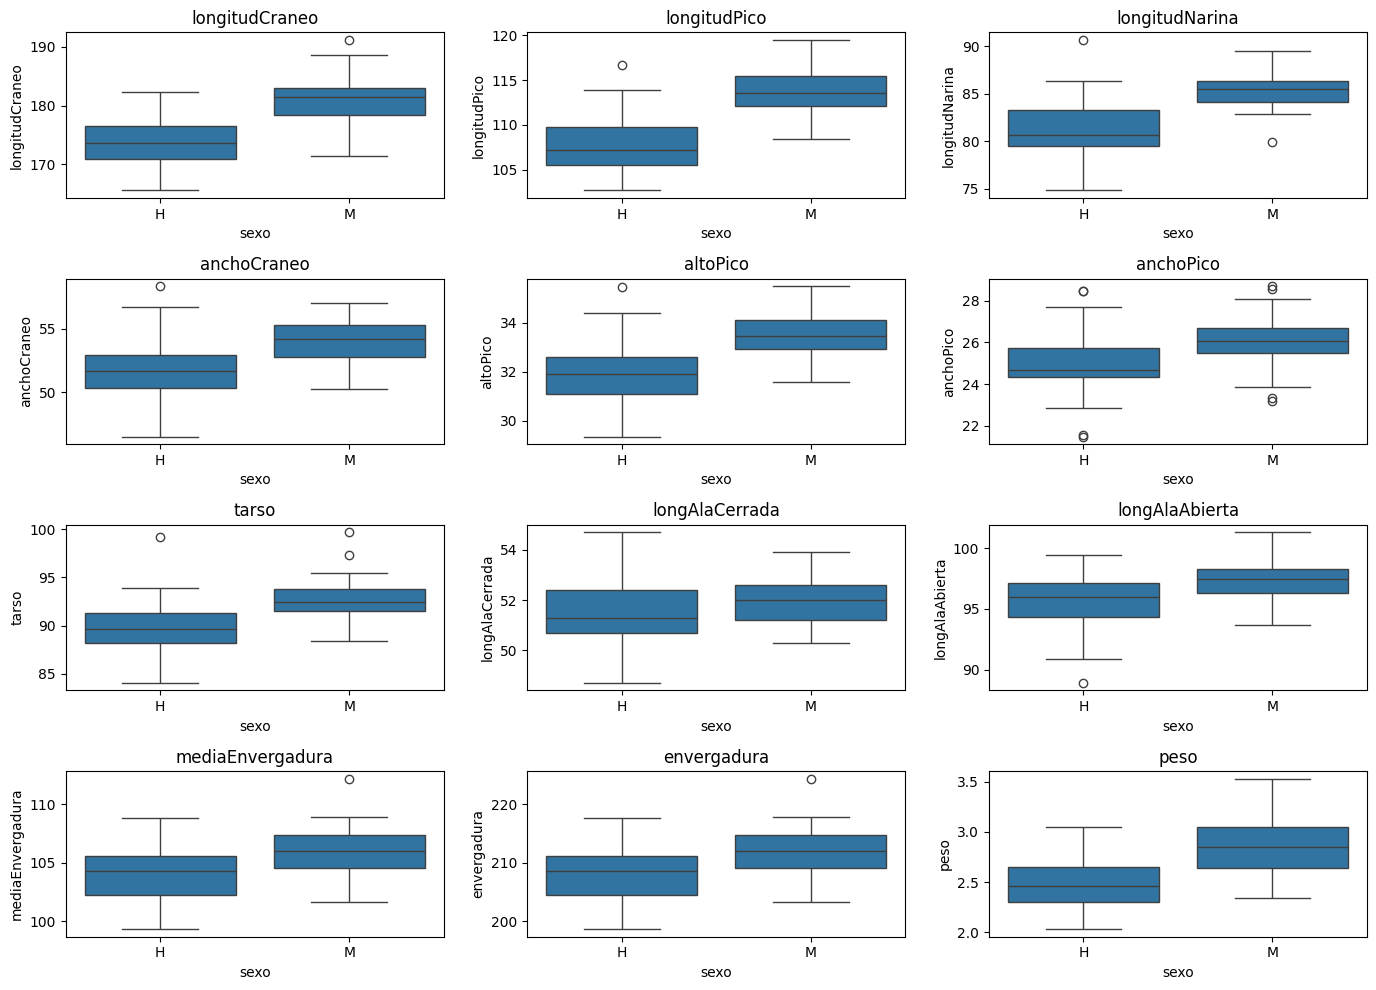

In [13]:
numeric_features = train.select_dtypes(include=np.number).columns.tolist()

numeric_features.remove("id") if "id" in numeric_features else None

plt.figure(figsize=(14, 10))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=train, x="sexo", y=col)
    plt.title(col)

plt.tight_layout()
plt.show()

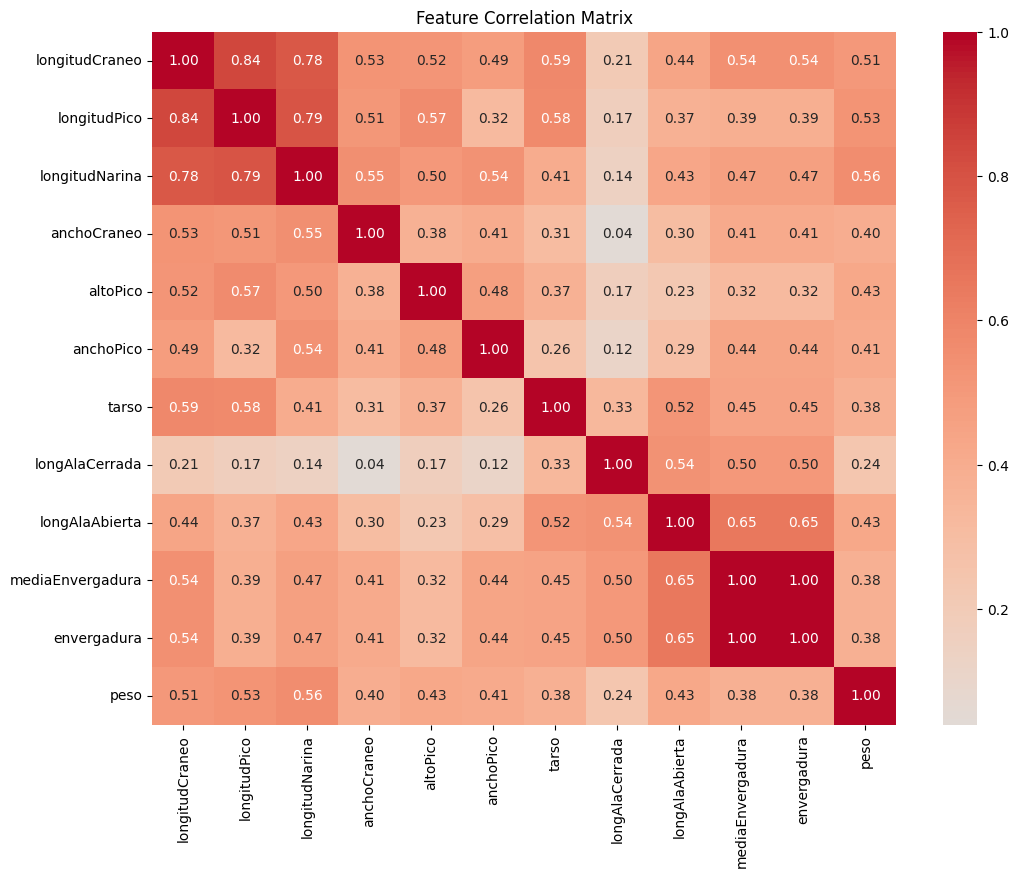

In [14]:
plt.figure(figsize=(12, 9))

corr = train[numeric_features].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [15]:
def create_features(df):

    data = df.copy()

    # Remove ID from modelling features
    if "id" in data.columns:
        data = data.drop(columns=["id"])

    # -------------------------------
    # Ratio / shape features
    # -------------------------------

    data["beak_skull_ratio"] = (
        data["longitudPico"] / data["longitudCraneo"]
    )

    data["nostril_beak_ratio"] = (
        data["longitudNarina"] / data["longitudPico"]
    )

    data["beak_width_length_ratio"] = (
        data["anchoPico"] / data["longitudPico"]
    )

    data["beak_depth_length_ratio"] = (
        data["altoPico"] / data["longitudPico"]
    )

    data["skull_width_length_ratio"] = (
        data["anchoCraneo"] / data["longitudCraneo"]
    )

    data["tarsus_skull_ratio"] = (
        data["tarso"] / data["longitudCraneo"]
    )

    data["weight_skull_ratio"] = (
        data["peso"] / data["longitudCraneo"]
    )

    data["weight_wingspan_ratio"] = (
        data["peso"] / data["mediaEnvergadura"]
    )

    data["open_closed_wing_ratio"] = (
        data["longAlaAbierta"] / data["longAlaCerrada"]
    )

    data["openwing_wingspan_ratio"] = (
        data["longAlaAbierta"] / data["mediaEnvergadura"]
    )

    # --------------------------------
    # Derived wingspan consistency
    # --------------------------------

    data["wingspan_difference"] = (
        data["envergadura"] -
        2 * data["mediaEnvergadura"]
    )

    data["wingspan_ratio"] = (
        data["envergadura"] /
        (2 * data["mediaEnvergadura"])
    )

    # Replace infinite values
    data = data.replace([np.inf, -np.inf], np.nan)

    return data

In [16]:
X = train.drop(columns=["sexo"])
y = train["sexo"]

X_test = test.copy()

X = create_features(X)
X_test = create_features(X_test)

print("Training features:", X.shape)
print("Test features:", X_test.shape)

display(X.head())

Training features: (94, 24)
Test features: (41, 24)


,longitudCraneo,longitudPico,longitudNarina,anchoCraneo,altoPico,anchoPico,tarso,longAlaCerrada,longAlaAbierta,mediaEnvergadura,...,beak_width_length_ratio,beak_depth_length_ratio,skull_width_length_ratio,tarsus_skull_ratio,weight_skull_ratio,weight_wingspan_ratio,open_closed_wing_ratio,openwing_wingspan_ratio,wingspan_difference,wingspan_ratio
0,174.18,106.85,80.19,52.43,30.20,23.26,88.74,51.0,95.7,104.2,...,0.217688,0.282639,0.301010,0.509473,0.013664,0.022841,1.876471,0.918426,0.0,1.0
1,171.12,104.59,79.45,51.14,30.61,24.04,90.22,50.5,94.4,102.2,...,0.229850,0.292667,0.298855,0.527232,0.012506,0.020939,1.869307,0.923679,0.0,1.0
2,174.69,106.83,82.14,49.09,30.60,26.47,91.42,52.7,96.6,105.2,...,0.247777,0.286436,0.281012,0.523327,0.014311,0.023764,1.833017,0.918251,0.0,1.0
3,182.25,113.17,84.13,52.26,32.08,26.07,91.74,52.6,98.9,107.6,...,0.230361,0.283467,0.286749,0.503374,0.015528,0.026301,1.880228,0.919145,0.0,1.0
4,173.70,105.19,80.37,49.20,34.00,27.12,87.77,50.8,94.5,103.7,...,0.257819,0.323225,0.283247,0.505296,0.015717,0.026326,1.860236,0.911283,0.0,1.0


In [17]:
y_encoded = y.map({
    "H": 0,
    "M": 1
})

print(y_encoded.value_counts())

sexo
0    57
1    37
Name: count, dtype: int64


In [18]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    stratify=y_encoded,
    random_state=RANDOM_STATE
)

print("Training:", X_train.shape)
print("Validation:", X_valid.shape)

Training: (75, 24)
Validation: (19, 24)


In [19]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=1,
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train)

pred_logistic = logistic_model.predict(X_valid)

print("Logistic Regression")
print("Accuracy :", accuracy_score(y_valid, pred_logistic))
print("Precision:", precision_score(y_valid, pred_logistic))
print("Recall   :", recall_score(y_valid, pred_logistic))
print("F1 Score :", f1_score(y_valid, pred_logistic))

Logistic Regression
Accuracy : 0.8947368421052632
Precision: 0.8571428571428571
Recall   : 0.8571428571428571
F1 Score : 0.8571428571428571


In [20]:
svm_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVC(
        C=5,
        gamma=0.0003,
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

svm_model.fit(X_train, y_train)

pred_svm = svm_model.predict(X_valid)

print("SVM")
print("Accuracy :", accuracy_score(y_valid, pred_svm))
print("Precision:", precision_score(y_valid, pred_svm))
print("Recall   :", recall_score(y_valid, pred_svm))
print("F1 Score :", f1_score(y_valid, pred_svm))

SVM
Accuracy : 0.8947368421052632
Precision: 0.8571428571428571
Recall   : 0.8571428571428571
F1 Score : 0.8571428571428571


In [21]:
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=5,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_valid)

print("Random Forest")
print("Accuracy :", accuracy_score(y_valid, pred_rf))
print("Precision:", precision_score(y_valid, pred_rf))
print("Recall   :", recall_score(y_valid, pred_rf))
print("F1 Score :", f1_score(y_valid, pred_rf))

Random Forest
Accuracy : 0.8947368421052632
Precision: 0.8571428571428571
Recall   : 0.8571428571428571
F1 Score : 0.8571428571428571


In [22]:
extra_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesClassifier(
        n_estimators=1000,
        max_depth=5,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

extra_model.fit(X_train, y_train)

pred_extra = extra_model.predict(X_valid)

print("Extra Trees")
print("Accuracy :", accuracy_score(y_valid, pred_extra))
print("Precision:", precision_score(y_valid, pred_extra))
print("Recall   :", recall_score(y_valid, pred_extra))
print("F1 Score :", f1_score(y_valid, pred_extra))

Extra Trees
Accuracy : 0.8947368421052632
Precision: 0.8571428571428571
Recall   : 0.8571428571428571
F1 Score : 0.8571428571428571


In [23]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "Extra Trees"
    ],
    "Accuracy": [
        accuracy_score(y_valid, pred_logistic),
        accuracy_score(y_valid, pred_svm),
        accuracy_score(y_valid, pred_rf),
        accuracy_score(y_valid, pred_extra)
    ],
    "Precision": [
        precision_score(y_valid, pred_logistic),
        precision_score(y_valid, pred_svm),
        precision_score(y_valid, pred_rf),
        precision_score(y_valid, pred_extra)
    ],
    "Recall": [
        recall_score(y_valid, pred_logistic),
        recall_score(y_valid, pred_svm),
        recall_score(y_valid, pred_rf),
        recall_score(y_valid, pred_extra)
    ],
    "F1": [
        f1_score(y_valid, pred_logistic),
        f1_score(y_valid, pred_svm),
        f1_score(y_valid, pred_rf),
        f1_score(y_valid, pred_extra)
    ]
})

results = results.sort_values("F1", ascending=False)

display(results)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.894737,0.857143,0.857143,0.857143
1,SVM,0.894737,0.857143,0.857143,0.857143
2,Random Forest,0.894737,0.857143,0.857143,0.857143
3,Extra Trees,0.894737,0.857143,0.857143,0.857143


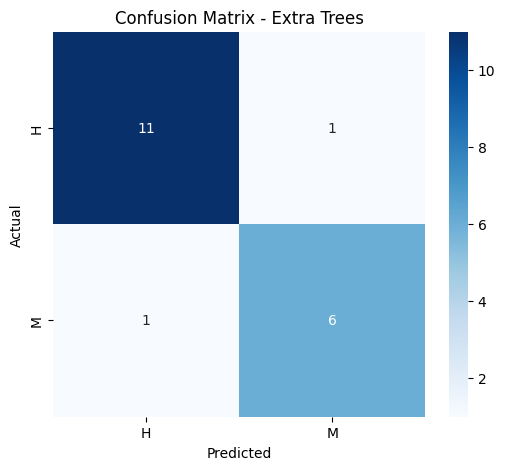

              precision    recall  f1-score   support

           H       0.92      0.92      0.92        12
           M       0.86      0.86      0.86         7

    accuracy                           0.89        19
   macro avg       0.89      0.89      0.89        19
weighted avg       0.89      0.89      0.89        19



In [24]:
best_predictions = pred_extra

cm = confusion_matrix(y_valid, best_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["H", "M"],
    yticklabels=["H", "M"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Extra Trees")

plt.show()

print(classification_report(
    y_valid,
    best_predictions,
    target_names=["H", "M"]
))

In [ ]:
cv = StratifiedKFold(
    n_splits=7,
    shuffle=True,
    random_state=RANDOM_STATE
)

models = {
    "Logistic Regression": logistic_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "Extra Trees": extra_model
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y_encoded,
        cv=cv,
        scoring="f1"
    )

    cv_results.append({
        "Model": name,
        "Mean F1": scores.mean(),
        "Std F1": scores.std()
    })

cv_results = pd.DataFrame(cv_results)
cv_results = cv_results.sort_values("Mean F1", ascending=False)

display(cv_results)

In [ ]:
extra_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

param_grid_extra = {
    "model__n_estimators": [500, 1000],
    "model__max_depth": [3, 4, 5, 6, None],
    "model__min_samples_split": [2, 4, 6],
    "model__min_samples_leaf": [1, 2, 3],
    "model__max_features": ["sqrt", "log2", None]
}

grid_extra = GridSearchCV(
    extra_pipeline,
    param_grid=param_grid_extra,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_extra.fit(X, y_encoded)

print("Best parameters:")
print(grid_extra.best_params_)

print("\nBest CV F1:")
print(grid_extra.best_score_)

In [ ]:
svm_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVC(
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

param_grid_svm = {
    "model__C": [0.1, 0.5, 1, 2, 5, 10, 20],
    "model__gamma": [
        "scale",
        0.0001,
        0.0003,
        0.001,
        0.003,
        0.01,
        0.03
    ],
    "model__kernel": ["rbf", "linear"]
}

grid_svm = GridSearchCV(
    svm_pipeline,
    param_grid=param_grid_svm,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X, y_encoded)

print("Best SVM parameters:")
print(grid_svm.best_params_)

print("\nBest SVM CV F1:")
print(grid_svm.best_score_)

In [ ]:
print("Extra Trees CV F1:", grid_extra.best_score_)
print("SVM CV F1:", grid_svm.best_score_)

In [ ]:
from sklearn.model_selection import cross_val_predict

# Use the better tuned model
best_model = grid_extra if grid_extra.best_score_ >= grid_svm.best_score_ else grid_svm

oof_prob = cross_val_predict(
    best_model.best_estimator_,
    X,
    y_encoded,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_results = []

for threshold in np.arange(0.20, 0.81, 0.01):

    oof_pred = (oof_prob >= threshold).astype(int)

    score = f1_score(
        y_encoded,
        oof_pred
    )

    threshold_results.append({
        "threshold": threshold,
        "f1": score
    })

threshold_df = pd.DataFrame(threshold_results)

best_threshold = threshold_df.loc[
    threshold_df["f1"].idxmax(),
    "threshold"
]

best_threshold_f1 = threshold_df["f1"].max()

print("Best threshold:", best_threshold)
print("OOF F1:", best_threshold_f1)

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"]
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Classification Threshold")
plt.legend()

plt.show()

In [ ]:
final_model = best_model.best_estimator_

final_model.fit(
    X,
    y_encoded
)

print("Final model trained on all training data.")

In [ ]:
test_prob = final_model.predict_proba(X_test)[:, 1]

# Use 0.50 initially
test_pred_numeric = (test_prob >= 0.50).astype(int)

test_predictions = np.where(
    test_pred_numeric == 1,
    "M",
    "H"
)

print(pd.Series(test_predictions).value_counts())

In [ ]:
submission = pd.DataFrame({
    "id": test["id"],
    "sexo": test_predictions
})

display(submission.head(10))

print("Submission shape:", submission.shape)

In [ ]:
assert len(submission) == len(test), \
    "Submission row count does not match test set."

assert submission["id"].equals(test["id"]), \
    "Submission IDs do not match test IDs."

assert submission["sexo"].isin(["H", "M"]).all(), \
    "sexo contains values other than H or M."

assert submission["id"].is_unique, \
    "Duplicate IDs found."

print("✓ Row count correct")
print("✓ IDs match test.csv")
print("✓ Only H/M predictions")
print("✓ IDs are unique")
print("\nSubmission format is valid!")

In [ ]:
submission.to_csv(
    "/content/submission.csv",
    index=False
)

print("Saved successfully!")
print("/content/submission.csv")

In [ ]:
from google.colab import files

files.download("/content/submission.csv")